# CNN based Object Detector

## Prerequisites:

To learn CNN based Object detector, readers must have a proper understanding of a few basic concepts in Deep Learning like:

- Convolutional Neural Network (CNN)
- Object Localization, Concept of Bounding Box
- CNN based Image Classification
- CNN based Object Localization, Concept of Regression Head

## Learning Objective:

By the end of this lesson, the student will be able to:

- Explain the concept of regression, classification head and backbone network in his/her own words.

- Explain the way of assembling the backbone, regression and classification heads together to obtain an object detection model.

- Visualize the concept of a simple object detector, where the predictions are made from a single feature map of the last layer of the backbone network.


## 1. Multiple Object Localizer

Let's recap the architecture of the CNN based Localizer first. Figure 1 (a) shows a simple architecture using a GAP layer. We used a CNN backbone to generate the feature map of the image. Then, the feature map was passed to a GAP or Flatten layer to get the feature vector. This feature vector is the a $1$ - dimensional encoding / representation of the **full image**. Since the feature vector is $1$ - dimensional, it's termed as a vector. This feature vector was then passed to a fully connected regression head to get the $4$ values for the bounding box.

Since the CNN backbone and the GAP together provides a 1-dimensional vector representation for the full image, we can call the combination a feature vectorizer. It simplifies further reading. Thus the simplified representation of Localizer is shown in figure 1 (b). Hence, the basic idea behind a CNN-based localizer is to get the $1$ - dimensional vector representation (feature vector) for the **full image** using a convolutional network and then pass it to a fully connected network.

<!-- <center>
<img src="https://drive.google.com/uc?export=view&id=1tZ4QkAGONI4b0uFB-BHa1-pJHgPNv7qE" alt="centered image" align='center' width = 800px/> -->
<center>
<img src="https://i.postimg.cc/fL4rcqm4/image.png" alt="centered image" align='center' width = 800px/>

(a)

<!-- <img src="https://drive.google.com/uc?export=view&id=1s0RIvq6ptrXrlWkmxELMDGVqZKvrisNd" alt="centered image" align='center' width = 600px/> -->
<img src="https://i.postimg.cc/QdqXF5TJ/image.png" alt="centered image" align='center' width = 600px/>

(b)

Figure 1: Architecture of CNN based Localizer
</center>



The localizer architecture shown above generates only four values for the bounding box. Can it fit a detection problem where there are multiple objects to be predicted? No. So how can we tackle the detection problem with a CNN?

We will combine the idea that CNN preserves the relative spatial association of information in the image with the concept we used to build the CNN based Localizer. CNN pools information from an image such that the feature map stores it in a corresponding location. Figure 2 demonstrates this. The input image of size $(300 \times 300)$ is shown on the left. The $5 \times 5$ feature map, produced by some CNN, is shown on the right. Let's convert the input image into subsections with a $ 5\times 5 $ grid. In figure 2(a), the top-left cell of the input image grid is highlighted with a dark blue square, and the corresponding top left slice of the feature map is highlighted with dark blue color. The CNN holds the property that the dark highlighted slice in the feature map stores the highlighted grid cell's information in the image grid. Figures 2(b) and 2(c) show the preservation of such spatial association.                


<!-- <center>
<img src="https://drive.google.com/uc?export=view&id=1oYpVUIg0HV0VVnyTNnrEEcES57J1S3Dt" alt="centered image" align='center' width = 500px/> -->
<center>
<img src="https://i.postimg.cc/g0QSHt9y/image.png" alt="centered image" align='center' width = 500px/>

(a)

<!-- <img src="https://drive.google.com/uc?export=view&id=17aiIIA4OBwYQHz7she394wiMdG2QAV3A" alt="centered image" align='center' width = 500px/> -->
<img src="https://i.postimg.cc/MGnf1q8T/image.png" alt="centered image" align='center' width = 500px/>

(b)

<!-- <img src="https://drive.google.com/uc?export=view&id=1DPscODivJyudHJMHZUq4no3cbIX3eesF" alt="centered image" align='center' width = 500px/> -->
<img src="https://i.postimg.cc/prsnDTym/image.png" alt="centered image" align='center' width = 500px/>

(c)



Figure 2: Preservation of spatial data of an image in the feature map
</center>




A slice of the feature map stores information about a region of the image. Hence, we can take it as the feature vector for the part of the image. In other words, that slice of the feature map represents the region of the image. We can use the slice to localize the object of interest if the region part contains any.


We know that the object detection problem requires localizing and categorizing multiple objects in a single image. However, let's focus on the problem of localizing multiple objects in a single image, ignoring the need to categorize them.

Combining the above ideas, we can use a $m \times m$ feature map, obtained from a CNN, for localizing multiple objects. To understand how we convert the input image into $m \times m$ grid. We take $m$ to be equal to 5 in the figures here. Using the idea of spatial preservation of information, we can expect that each slice in the feature map stores the information in the image's corresponding region. These $m \times m$ slices of the feature map can then be passed to regression heads as in Localizer in batch or individually to get the location of objects in the respective image grid cells. This setting enables us to localize at most $m^2$ objects in the image. Figure 3(a) and 3(b) illustrate localization for the top-left grid cell and the former's grid cell right.

<!-- <center>
<img src="https://drive.google.com/uc?export=view&id=1uUVAuMrA5X-RskKdESuXJxaR9-6iyo86" alt="centered image" align='center' width = 800px/> -->
<center>
<img src="https://drive.google.com/uc?export=view&id=1uUVAuMrA5X-RskKdESuXJxaR9-6iyo86" alt="centered image" align='center' width = 800px/>

(a)


<img src="https://drive.google.com/uc?export=view&id=1wsq98oVM7Q-Sm_omvGHWvRFhAy59EpbC" alt="centered image" align='center' width = 800px/>

(b)

Figure 3: Multi-object Localizer with fully connected Regression Head
</center>

It turns out that we don't need to pass the feature map slices to fully connected individually or in batch. The task with 2-layer fully connected subnetwork is done by a 2-layer $1 \times 1$ convolutional layer subnetwork.  We call this subnetwork a $1 \times 1$ convolutional regression head. Figure 4(a) illustrates the multi-object localizer architecture. Similarly, figure 4(b) shows that the top left part of the output tensor is the localization prediction for the top left part of the image. We can use similar convolutional heads for classification. During training, its outputs are passed to classification loss functions, unlike the regression head outputs.

<center>
<img src="https://i.postimg.cc/qB6RwjYm/image.png" alt="centered image" align='center' width = 800px/>

(a)


<!-- <img src="https://drive.google.com/uc?export=view&id=1uTxtviIAVP5Pxsl0zHsrIevydrXu_UnN" alt="centered image" align='center' width = 800px/> -->
<img src="https://i.postimg.cc/qvfRhyvN/image.png" alt="centered image" align='center' width = 800px/>

(b)

Figure 4: Multi-object Localizer with convolutional Regression Head
</center>



## 2. Components of Object Detector

As we know, object detection needs to localize and categorize multiple objects in a single image. We can combine a classification head, similar in structure with localization head into the multi-object Localizer.  Figure 5 shows the underlying architecture for a simple face detector—the heads output localization and classification prediction tensors.

1. **Backbone Network**    
A backbone generates the feature map of the input image. This feature map is then passed to both localization and classification heads. The backbone is usually a CNN model, pre-trained on massive datasets like Imagenet.  

2. **Localization Head** - The localization head is a fully convolutional sub-network. It's similar to the fully convolutional regression head discussed earlier. It takes in the feature map obtained from the backbone network and outputs the localization prediction tensor. During training, the localization prediction tensors are passed to regression loss functions. Each channel in the localization prediction tensor corresponds to $(x1, y1, x2, y2)$.

3. **Classification Head** - The classification head is another fully convolutional sub-network. It also takes in the feature map from the backbone network and outputs the classification prediction tensor.  During training, the classification prediction tensors are passed to classification loss functions. Each channel in the classification tensor resembles a specific category or class. A common practice is to include an additional channel for background for those objects that are not of interest. For example, for a face detection class, the classification prediction tensor has two channels, one for face and another for non-face.


<!-- <center>
<img src="https://drive.google.com/uc?export=view&id=1ksOQH8Q9m3GpXFvFhuPznBSfVq9NF7GE" alt="centered image" align='center' width = 800px/> -->
<center>
<img src="https://i.postimg.cc/Wzz3gcK8/image.png" alt="centered image" align='center' width = 800px/>

Figure 5: Architecture of a Face Detector
</center>

Another typical architecture is to predict the classification and localization values by a single sub-network called detection head. The prediction tensor thus obtained consists of localization values and classification values partly.    


In [ ]:
import torch
import torchvision
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, sampler, random_split, Dataset
import copy
import math
from PIL import Image
import cv2
import os
import sys
import pandas as pd
import numpy as np
import albumentations as A  # our data augmentation library

import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
# remove warnings (optional)
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict, deque
import datetime
import time
from tqdm import tqdm # progress bar
from torchvision.utils import draw_bounding_boxes

In [ ]:
# our dataset is in cocoformat, we will need pypcoco tools
!pip install pycocotools
from pycocotools.coco import COCO

In [ ]:
# Now, we will define our transforms
from albumentations.pytorch import ToTensorV2

In [ ]:
def get_transforms(train=False):
    if train:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            A.HorizontalFlip(p=0.3),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.1),
            A.ColorJitter(p=0.1),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    else:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    return transform

In [ ]:
class AquariumDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        # the 3 transform parameters are reuqired for datasets.VisionDataset
        super().__init__(root, transforms, transform, target_transform)
        self.split = split #train, valid, test
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json")) # annotatiosn stored here
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]

    def _load_image(self, id: int):
        path = self.coco.loadImgs(id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image
    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = self._load_target(id)
        target = copy.deepcopy(self._load_target(id))

        boxes = [t['bbox'] + [t['category_id']] for t in target] # required annotation format for albumentations
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)

        image = transformed['image']
        boxes = transformed['bboxes']

        new_boxes = [] # convert from xywh to xyxy
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(new_boxes, dtype=torch.float32)

        targ = {} # here is our transformed target
        targ['boxes'] = boxes
        targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64)
        targ['image_id'] = torch.tensor([t['image_id'] for t in target])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # we have a different area
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64)
        return image.div(255), targ # scale images
    def __len__(self):
        return len(self.ids)

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')



Mounted at /content/gdrive


In [ ]:
dataset_path="/content/gdrive/MyDrive/Aquarium Combined"

In [ ]:
#load classes
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=3.94s)
creating index...
index created!


{0: {'id': 0, 'name': 'creatures', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'fish', 'supercategory': 'creatures'},
 2: {'id': 2, 'name': 'jellyfish', 'supercategory': 'creatures'},
 3: {'id': 3, 'name': 'penguin', 'supercategory': 'creatures'},
 4: {'id': 4, 'name': 'puffin', 'supercategory': 'creatures'},
 5: {'id': 5, 'name': 'shark', 'supercategory': 'creatures'},
 6: {'id': 6, 'name': 'starfish', 'supercategory': 'creatures'},
 7: {'id': 7, 'name': 'stingray', 'supercategory': 'creatures'}}

In [ ]:
classes = [i[1]['name'] for i in categories.items()]
classes

['creatures',
 'fish',
 'jellyfish',
 'penguin',
 'puffin',
 'shark',
 'starfish',
 'stingray']

In [ ]:
train_dataset = AquariumDetection(root=dataset_path, transforms=get_transforms(True))

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


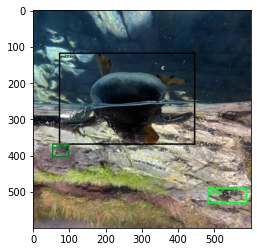

In [ ]:
# Lets view a sample
sample = train_dataset[2]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [ ]:
# lets load the faster rcnn model
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features # we need to change the head
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


  0%|          | 0.00/74.2M [00:00<?, ?B/s]

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn=collate_fn)

In [ ]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [ ]:
device = torch.device("cuda") # use GPU to train

In [ ]:
model = model.to(device)

In [ ]:
# Now, and optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)
# lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[16, 22], gamma=0.1) # lr scheduler

In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.to(device)
    model.train()

#     lr_scheduler = None
#     if epoch == 0:
#         warmup_factor = 1.0 / 1000 # do lr warmup
#         warmup_iters = min(1000, len(loader) - 1)

#         lr_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor = warmup_factor, total_iters=warmup_iters)

    all_losses = []
    all_losses_dict = []

    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        targets = [{k: torch.tensor(v).to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets) # the model computes the loss automatically if we pass in targets
        losses = sum(loss for loss in loss_dict.values())
        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()

        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)

        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping trainig") # train if loss becomes infinity
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

#         if lr_scheduler is not None:
#             lr_scheduler.step() #

    all_losses_dict = pd.DataFrame(all_losses_dict) # for printing
    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], np.mean(all_losses),
        all_losses_dict['loss_classifier'].mean(),
        all_losses_dict['loss_box_reg'].mean(),
        all_losses_dict['loss_rpn_box_reg'].mean(),
        all_losses_dict['loss_objectness'].mean()
    ))

In [ ]:
num_epochs=10

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
#     lr_scheduler.step()

100%|██████████| 112/112 [00:21<00:00,  5.18it/s]


Epoch 0, lr: 0.010000, loss: 0.696730, loss_classifier: 0.287026, loss_box: 0.339656, loss_rpn_box: 0.025667, loss_object: 0.044382


100%|██████████| 112/112 [00:22<00:00,  5.01it/s]


Epoch 1, lr: 0.010000, loss: 0.657734, loss_classifier: 0.259228, loss_box: 0.333680, loss_rpn_box: 0.024682, loss_object: 0.040143


100%|██████████| 112/112 [00:20<00:00,  5.57it/s]


...

Epoch 7, lr: 0.010000, loss: 0.630574, loss_classifier: 0.226313, loss_box: 0.359623, loss_rpn_box: 0.020236, loss_object: 0.024402


100%|██████████| 112/112 [00:19<00:00,  5.62it/s]


Epoch 8, lr: 0.010000, loss: 0.612597, loss_classifier: 0.220511, loss_box: 0.349801, loss_rpn_box: 0.020061, loss_object: 0.022225


100%|██████████| 112/112 [00:20<00:00,  5.36it/s]

Epoch 9, lr: 0.010000, loss: 0.603809, loss_classifier: 0.214423, loss_box: 0.346750, loss_rpn_box: 0.019121, loss_object: 0.023515


In [ ]:
# we will watch first epoich to ensure no errrors
# while it is training, lets write code to see the models predictions. lets try again
model.eval()
torch.cuda.empty_cache()

In [ ]:
test_dataset = AquariumDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=2.53s)
creating index...
index created!


In [ ]:
img, _ = test_dataset[5]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

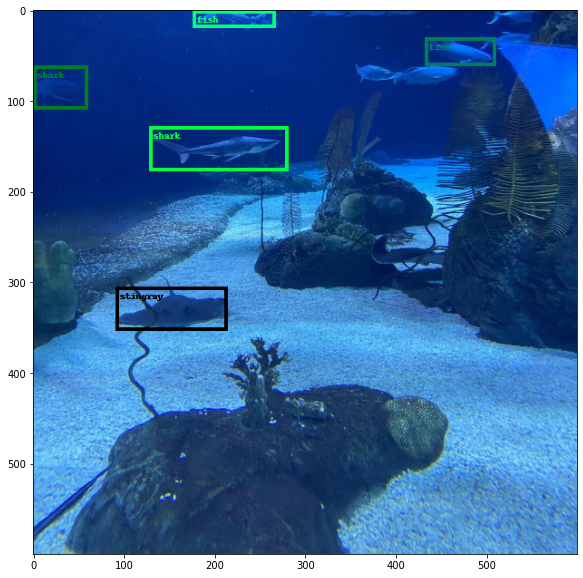

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))